# FOMC Speaker Hawk/Dove — Hand-Labelled Quarterly Stances, 2019 – 2026

The sibling of `usd_fomc_speaker_hawk_dove_backtest.ipynb`. Same instrument, same engine, same
Fed-specific cuts — one thing changes: **the label**.

Instead of inferring a speaker's committee position from the dispersion of an NLP score, every
FOMC speaker is **hand-labelled hawk/dove for each calendar quarter**, 2019Q1 – 2026Q3, from
published consensus: dated Reuters *Doves-and-Hawks* grids, recorded dissents, dot-plot positions
and named press characterisations. 31 speakers, 119 stance periods, 476 labelled speaker-quarters,
documented in `FED_SPEAKER_QUARTERLY_LABELS.md`.

### Why quarterly

A fixed label per person cannot represent a committee that rotates. Christopher Waller was the
FOMC's leading hawk through 2021-23 (`+2`, *"go early and go fast"*), fell to its dovish extreme by
2025Q3 when he dissented for cuts (`-2`), and is back at the median in 2026. **13 speakers move a
full two notches.** The label has to move with them.

### Two consequences of hand-labelling

**It widens the universe.** A hand label needs no NLP score, so every FOMC speaker the calendar
carries becomes tradeable — not only the speeches JPM chose to score. 473 trades → **783**.

**It reaches back to 2019.** The JPM corpus's first report is 2023-05-02, so a point-in-time
score-based study cannot start earlier. Hand labels have no such floor.

### The instrument had to change to get there

SR3 barely existed before the LIBOR transition. Measured on the 3rd quarterly contract:

| date | Eurodollar (GE) | SOFR (SR3) |
|---|---|---|
| 2021-03-10 | **541 bars / 3 px** | 37 bars / 3 px |
| 2021-09-15 | **379 / 4** | 61 / 2 |
| 2022-01-12 | 515 / 9 | 331 / 12 |
| 2022-09-14 | 809 / 33 | **926 / 29** |

Trading SOFR futures in 2019-2021 is trading a contract that was not there, so the USD leg
**splices GE → SR3 at 2022-01-01**, where the two converge.

---

> ## ⚠ These labels are not point-in-time
>
> They were assigned in 2026 from commentary covering the whole period, so a quarter's stance can
> encode what was only understood later — that a speaker turned dovish in 2025Q3 is partly known
> *because* of what followed.
>
> This notebook therefore measures **what a correct, quarterly-refreshed read of the committee
> would have been worth** — the ceiling on the idea — not what a desk could have earned. The
> causal comparison is the `peer` scheme on identical machinery: 473 trades, Sharpe 0.689,
> −14.7bp after a 0.25bp cost.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pickle, datetime, json
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-gcb"
HERE = Path(REPO) / "notebooks" / "backtests" / "intraday_fed_hawk_dove"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})

import global_hawk_dove_common as G
import fomc_extras as FX
from global_hawk_dove_run import CACHE, BASE_BPV, ENTRY_OFFSET, EXIT_OFFSET, CONTRACT_RANK

BANK = "FED"
cfg = G.CB_CONFIGS[BANK]
LABELS = G.load_quarterly_labels(HERE / "fed_quarterly_labels.json")

print(f"labels       : {len(LABELS)} speakers, "
      f"{sum(len(v.get('periods', [])) for v in LABELS.values())} stance periods")
print(f"instrument   : {cfg.root_for(datetime.date(2019,6,1))} -> "
      f"{cfg.root_for(datetime.date(2024,6,1))}  (splice 2022-01-01)")
print(f"entry / exit : T{int(ENTRY_OFFSET.total_seconds()//60):+d}m / "
      f"T{int(EXIT_OFFSET.total_seconds()//60):+d}m, {CONTRACT_RANK}rd quarterly, "
      f"base bpv {BASE_BPV:,.0f}")

C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\global_hawk_dove_common.py:47: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  from rateslib.scheduling import next_imm


labels       : 31 speakers, 119 stance periods
instrument   : GE -> SR3  (splice 2022-01-01)
entry / exit : T-45m / T+180m, 3rd quarterly, base bpv 100,000


## 1. The labels

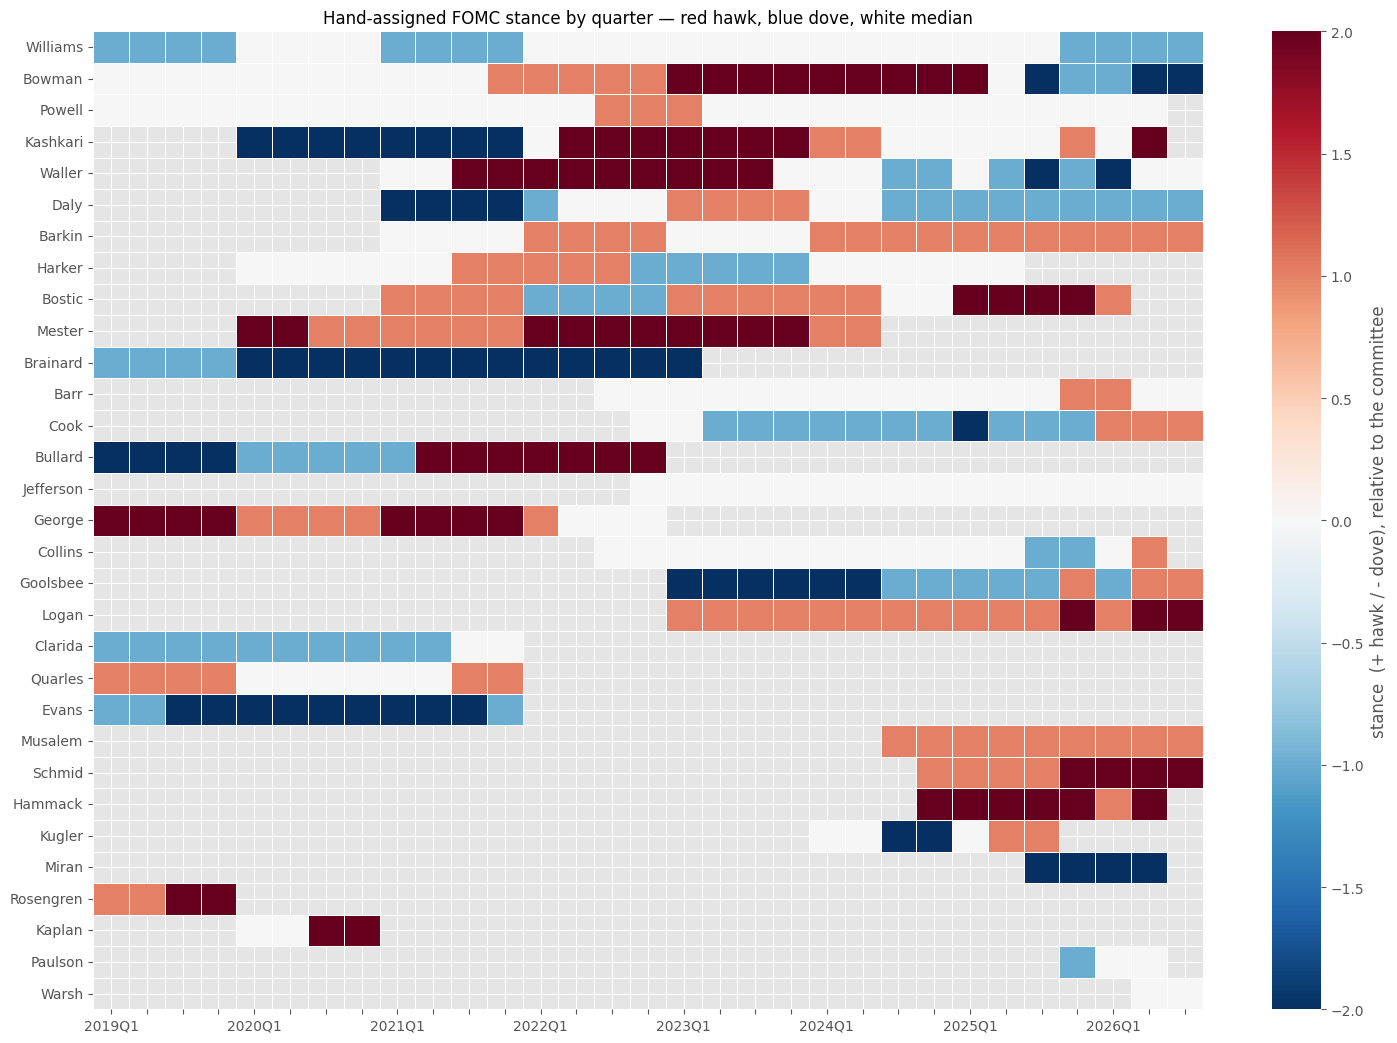

31 speakers, 476 labelled speaker-quarters
overall split — hawk 37.0%, neutral 34.9%, dove 28.2%


In [2]:
QUARTERS = [f"{y}Q{q}" for y in range(2019, 2027) for q in (1, 2, 3, 4)][:31]

def qi(q):
    y, n = q.upper().split("Q"); return int(y) * 4 + int(n) - 1

grid = {}
for sp, v in LABELS.items():
    row = {}
    for p in v.get("periods", []):
        lo, hi = qi(p["start_q"]), qi(p["end_q"])
        for q in QUARTERS:
            if lo <= qi(q) <= hi:
                row[q] = int(p["stance"])
    if row:
        grid[sp] = row

mat = pd.DataFrame(grid).T.reindex(columns=QUARTERS)
mat = mat.loc[mat.notna().sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(15, max(6, .34 * len(mat))))
sns.heatmap(mat.astype(float), cmap="RdBu_r", center=0, vmin=-2, vmax=2,
            linewidths=.4, linecolor="white", ax=ax,
            cbar_kws={"label": "stance  (+ hawk / - dove), relative to the committee"})
ax.set_title("Hand-assigned FOMC stance by quarter — red hawk, blue dove, white median")
ax.set_xticklabels([q if q.endswith("Q1") else "" for q in QUARTERS], rotation=0)
plt.tight_layout(); plt.show()

print(f"{len(mat)} speakers, {int(mat.notna().sum().sum())} labelled speaker-quarters")
print(f"overall split — hawk {(mat > 0).sum().sum() / mat.notna().sum().sum():.1%}, "
      f"neutral {(mat == 0).sum().sum() / mat.notna().sum().sum():.1%}, "
      f"dove {(mat < 0).sum().sum() / mat.notna().sum().sum():.1%}")

### 1.1 The committee rotates — which is why quarterly rebalancing exists

A label fixed per speaker would average these paths away.

13 of 31 speakers move by at least two notches


,min,max,path
speaker,,,
Bowman,-2,2,2019Q1:+0 → 2021Q4:+1 → 2023Q1:+2 → 2025Q2:+0 ...
Waller,-2,2,2021Q1:+0 → 2021Q3:+2 → 2023Q4:+0 → 2024Q3:-1 ...
Kashkari,-2,2,2020Q1:-2 → 2022Q1:+0 → 2022Q2:+2 → 2024Q1:+1 ...
Bullard,-2,2,2019Q1:-2 → 2020Q1:-1 → 2021Q2:+2
Daly,-2,1,2021Q1:-2 → 2022Q1:-1 → 2022Q2:+0 → 2023Q1:+1 ...
Bostic,-1,2,2021Q1:+1 → 2022Q1:-1 → 2023Q1:+1 → 2024Q3:+0 ...
Cook,-2,1,2022Q4:+0 → 2023Q2:-1 → 2025Q1:-2 → 2025Q2:-1 ...
Kugler,-2,1,2024Q1:+0 → 2024Q3:-2 → 2025Q1:+0 → 2025Q2:+1
Goolsbee,-2,1,2023Q1:-2 → 2024Q3:-1 → 2025Q4:+1 → 2026Q1:-1 ...


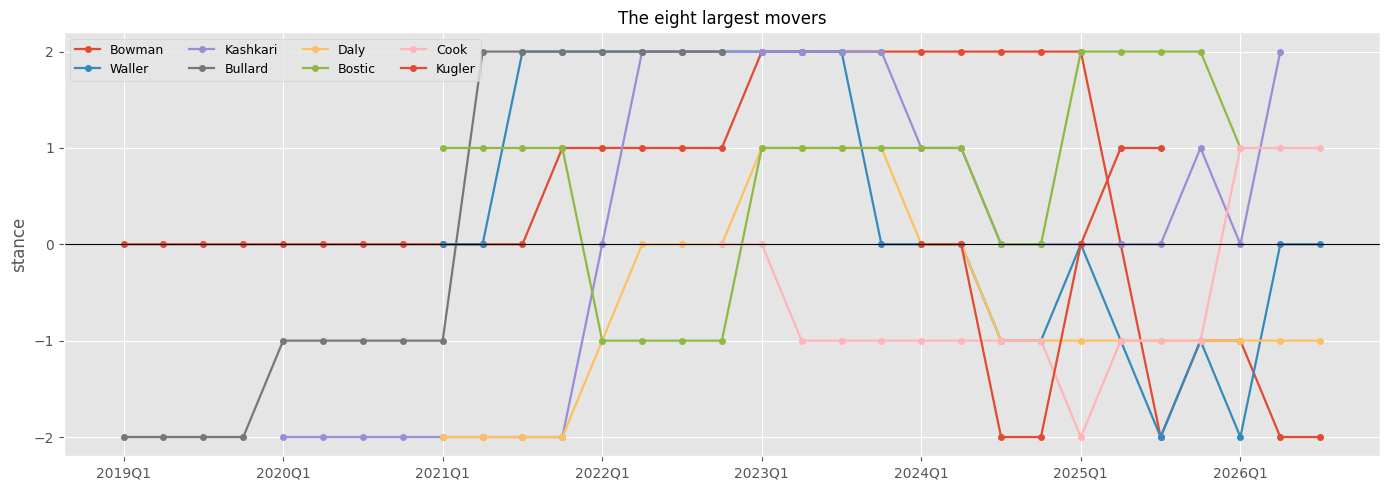

In [3]:
rng_ = (mat.max(axis=1) - mat.min(axis=1)).sort_values(ascending=False)
movers = rng_[rng_ >= 2].index.tolist()
print(f"{len(movers)} of {len(mat)} speakers move by at least two notches")

rows = []
for sp in movers:
    r = mat.loc[sp].dropna()
    path, last = [], None
    for q, v in r.items():
        if v != last:
            path.append(f"{q}:{int(v):+d}"); last = v
    rows.append({"speaker": sp, "min": int(r.min()), "max": int(r.max()),
                 "path": " → ".join(path)})
display(pd.DataFrame(rows).set_index("speaker"))

fig, ax = plt.subplots(figsize=(14, 5))
for sp in movers[:8]:
    r = mat.loc[sp].dropna()
    ax.plot([qi(q) for q in r.index], r.values, marker="o", ms=4, lw=1.6, label=sp)
ax.axhline(0, color="k", lw=.8)
ax.set_yticks([-2, -1, 0, 1, 2]); ax.set_ylabel("stance")
xt = [qi(q) for q in QUARTERS if q.endswith("Q1")]
ax.set_xticks(xt); ax.set_xticklabels([q for q in QUARTERS if q.endswith("Q1")])
ax.set_title("The eight largest movers"); ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Events and the causal-bar gate

Same gate as the score-based study: an event survives only where a genuine bar exists at-or-before
**both** entry and exit, within the staleness bound, on a day that is not a padded grid. That turns
pre-session lookahead, stale marks and fake zeros into logged exclusions rather than silent P&L.

In [4]:
with open(CACHE / "events_manual_manual.pkl", "rb") as f:
    ev_blob = pickle.load(f)[BANK]
events = ev_blob["events"]
f_ = ev_blob.get("funnel", {})

row = {"forexfactory rows": f_.get("n_forexfactory_rows", 0),
       "timed events": f_.get("n_timed", 0), "synthetic events": f_.get("n_synthetic", 0)}
row.update({f"ff excluded: {k}": v for k, v in (f_.get("forexfactory") or {}).items()})
row.update({f"syn excluded: {k}": v for k, v in (f_.get("synthetic") or {}).items()})
row.update({f"gate: {k}": v for k, v in (ev_blob.get("gate_reasons") or {}).items()})
row["TRADEABLE"] = len(events)
row["  of which synthetic"] = sum(1 for e in events if e.get("timestamp_source") == "synthetic")
display(pd.Series(row).to_frame("FOMC, hand labels"))
print("`unknown_speaker` has all but vanished: the hand roster covers every speaker the calendar")
print("carries, where the score-based universe was limited to speeches JPM chose to score.")

,"FOMC, hand labels"
forexfactory rows,1835
timed events,1035
synthetic events,129
ff excluded: neutral_or_no_score,583
ff excluded: window_too_short,149
ff excluded: not_business_day,58
ff excluded: policy_blackout,10
syn excluded: neutral_or_no_score,272
syn excluded: already_timed,263
syn excluded: not_business_day,29


`unknown_speaker` has all but vanished: the hand roster covers every speaker the calendar
carries, where the score-based universe was limited to speeches JPM chose to score.


## 3. Performance, 2019 – 2026

,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd
book,,,,,,,
equal weight (pnl_bp),783,221.0,0.2822,0.4649,0.7876,2.1677,-68.0
as sized (x |bucket|),783,347.5,0.4438,0.4649,0.8025,2.2087,-104.0


window: 2019-01-09 08:15:00-05:00  ->  2026-08-07 09:15:00-04:00


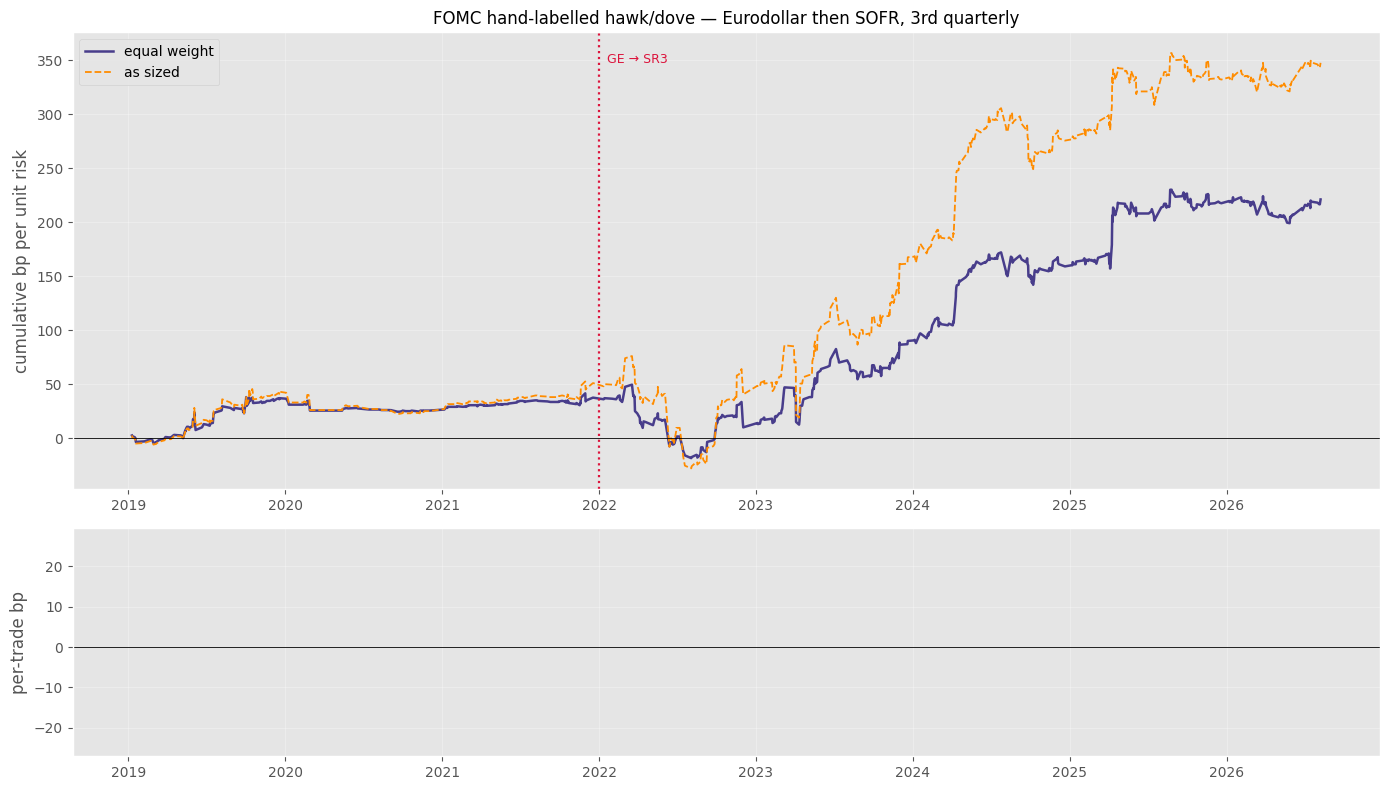

In [5]:
with open(CACHE / "closed_manual.pkl", "rb") as f:
    closed = pickle.load(f)[BANK].sort_values("opened_at").reset_index(drop=True)
ann = FX.annotate(closed)
ann["year"] = pd.to_datetime(ann.opened_at).dt.year
ann["era"] = np.where(ann.year < 2022, "Eurodollar (GE)", "SOFR (SR3)")

rows = []
for lbl, col in [("equal weight (pnl_bp)", "pnl_bp"), ("as sized (x |bucket|)", "pnl_bp_sized")]:
    if col not in closed.columns:
        continue
    s = G.summarize(closed, pnl_col=col)
    rows.append({"book": lbl, "trades": s["trades"], "total_bp": s["total"], "avg_bp": s["avg"],
                 "hit": s["hit_rate"], "sharpe": s["sharpe"], "t_stat": s["t_stat"],
                 "max_dd": s["max_dd"]})
display(pd.DataFrame(rows).set_index("book").round(4))
print(f"window: {closed.opened_at.min()}  ->  {closed.opened_at.max()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.plot(closed.opened_at.values, closed.pnl_bp.cumsum().values, lw=1.8,
        color="darkslateblue", label="equal weight")
if "pnl_bp_sized" in closed:
    ax.plot(closed.opened_at.values, closed.pnl_bp_sized.cumsum().values, lw=1.3,
            color="darkorange", ls="--", label="as sized")
sp_date = pd.Timestamp("2022-01-01", tz=closed.opened_at.dt.tz)
ax.axvline(sp_date, color="crimson", ls=":", lw=1.6)
ax.text(sp_date, ax.get_ylim()[1] * .95, "  GE → SR3", color="crimson", fontsize=9, va="top")
ax.axhline(0, color="k", lw=.6); ax.legend(); ax.grid(alpha=.3)
ax.set_ylabel("cumulative bp per unit risk")
ax.set_title("FOMC hand-labelled hawk/dove — Eurodollar then SOFR, 3rd quarterly")

ax = axes[1]
c = ["seagreen" if x > 0 else "indianred" for x in closed.pnl_bp]
ax.bar(closed.opened_at.values, closed.pnl_bp.values, color=c, width=3, alpha=.7)
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("per-trade bp"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3.1 Does it clear costs?

,all trades,real timestamps only,voters only
cost_bp_rt,,,
0.000,221.0,245.0,275.0
0.125,123.1,159.5,204.9
0.250,25.3,74.0,134.8
0.500,-170.5,-97.0,-5.5


break-even round trip: all 0.2822bp | real-ts 0.3582bp | voters 0.4902bp


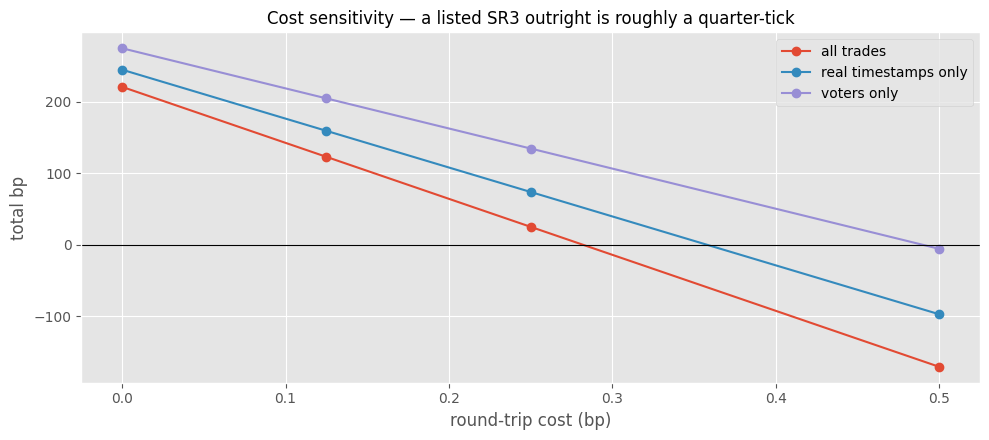

In [6]:
def blk(g, by):
    t = g.groupby(by, observed=False).agg(
        trades=("pnl_bp", "size"), total_bp=("pnl_bp", "sum"),
        avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"))
    t["t_stat"] = g.groupby(by, observed=False)["pnl_bp"].apply(
        lambda x: x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
        if len(x) > 2 and x.std() else np.nan)
    return t.round(4)

real = closed[closed.timestamp_source == "forexfactory"]
vot = ann[ann.is_voter == True]
books = {"all trades": closed.pnl_bp, "real timestamps only": real.pnl_bp,
         "voters only": vot.pnl_bp}
rows = []
for cost in [0.0, 0.125, 0.25, 0.5]:
    r = {"cost_bp_rt": cost}
    for nm, s in books.items():
        r[nm] = s.sum() - cost * len(s)
    rows.append(r)
cost_df = pd.DataFrame(rows).set_index("cost_bp_rt")
display(cost_df.round(1))
print(f"break-even round trip: all {closed.pnl_bp.mean():.4f}bp | "
      f"real-ts {real.pnl_bp.mean():.4f}bp | voters {vot.pnl_bp.mean():.4f}bp")

fig, ax = plt.subplots(figsize=(10, 4.5))
cost_df.plot(marker="o", ax=ax)
ax.axhline(0, color="k", lw=.8); ax.set_ylabel("total bp"); ax.set_xlabel("round-trip cost (bp)")
ax.set_title("Cost sensitivity — a listed SR3 outright is roughly a quarter-tick")
plt.tight_layout(); plt.show()

## 4. Who moves the market

Whether the speaker holds a vote that year is fixed by a rotation published years in advance, so
it is known at trade time and is not fitted to anything.

by voting status:


,trades,total_bp,avg_bp,hit,t_stat
is_voter,,,,,
does not vote,160,-59.5,-0.3719,0.4562,-1.0129
unknown,62,5.5,0.0887,0.4194,0.4244
votes this year,561,275.0,0.4902,0.4724,3.3589


by role:


,trades,total_bp,avg_bp,hit,t_stat
role,,,,,
Chair,9,22.0,2.4444,0.8889,0.9293
Governor,274,77.0,0.2810,0.4635,1.2203
President,444,98.0,0.2207,0.4617,1.3219
President (NY),56,24.0,0.4286,0.4286,1.2095


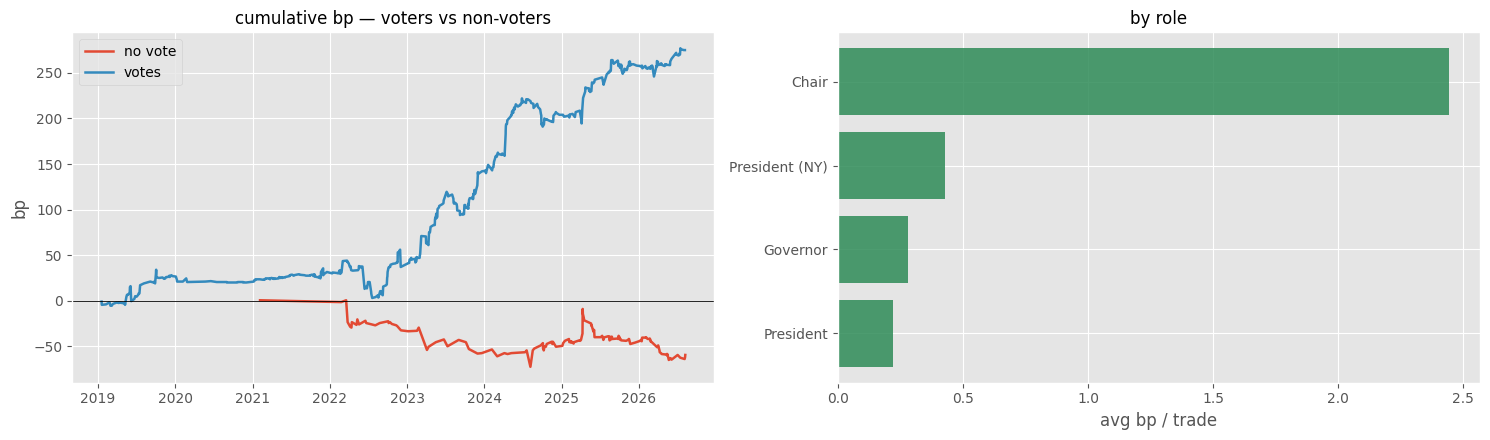

In [7]:
print("by voting status:")
display(blk(ann, ann["is_voter"].map({True: "votes this year", False: "does not vote"})
            .fillna("unknown")))
print("by role:")
display(blk(ann, "role"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
v = ann.dropna(subset=["is_voter"]).copy()
for lab, sub in v.groupby(v.is_voter.map({True: "votes", False: "no vote"})):
    sub = sub.sort_values("opened_at")
    axes[0].plot(sub.opened_at.values, sub.pnl_bp.cumsum().values, lw=1.8, label=lab)
axes[0].axhline(0, color="k", lw=.6); axes[0].legend()
axes[0].set_title("cumulative bp — voters vs non-voters"); axes[0].set_ylabel("bp")

r_ = ann.groupby("role")["pnl_bp"].mean().sort_values()
axes[1].barh(r_.index, r_.values,
             color=["indianred" if x < 0 else "seagreen" for x in r_.values], alpha=.85)
axes[1].axvline(0, color="k", lw=.6); axes[1].set_xlabel("avg bp / trade")
axes[1].set_title("by role")
plt.tight_layout(); plt.show()

### 4.1 The rotation as a natural experiment

Governors always vote, so "voters beat non-voters" might only be saying *governors matter more*.
Restricting to **regional presidents** removes that: same job, differing only by whether the
rotation happens to give them a vote that year — exogenous to what they say and to what the market
does.

,trades,total_bp,avg_bp,hit
group,,,,
"regional president, VOTING",278,176.0,0.6331,0.4676
"regional president, NOT voting",160,-59.5,-0.3719,0.4562


gap +1.0050 bp/trade   two-sided permutation p = 0.0034


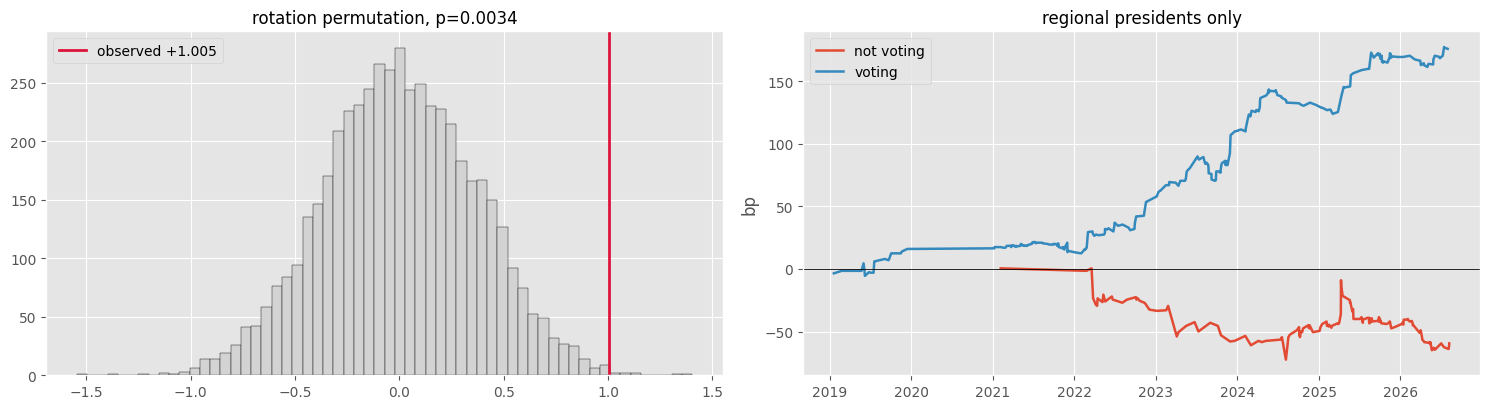

In [8]:
pres = ann[ann.role.isin(["President", "President (NY)"])].copy()
pres = pres[pres.is_voter.notna()]
pres["v"] = pres.is_voter.astype(bool)
a, b = pres.loc[pres.v, "pnl_bp"], pres.loc[~pres.v, "pnl_bp"]
obs = a.mean() - b.mean()

rng = np.random.default_rng(11)
f_arr, x_arr = pres.v.to_numpy(), pres.pnl_bp.to_numpy()
perm = np.empty(5000)
for i in range(5000):
    ff = rng.permutation(f_arr)
    perm[i] = x_arr[ff].mean() - x_arr[~ff].mean()
pval = float((np.abs(perm) >= abs(obs)).mean())

display(pd.DataFrame([
    {"group": "regional president, VOTING", "trades": len(a), "total_bp": a.sum(),
     "avg_bp": a.mean(), "hit": (a > 0).mean()},
    {"group": "regional president, NOT voting", "trades": len(b), "total_bp": b.sum(),
     "avg_bp": b.mean(), "hit": (b > 0).mean()},
]).set_index("group").round(4))
print(f"gap {obs:+.4f} bp/trade   two-sided permutation p = {pval:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
axes[0].hist(perm, bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(obs, color="crimson", lw=2, label=f"observed {obs:+.3f}")
axes[0].set_title(f"rotation permutation, p={pval:.4f}"); axes[0].legend()
for lab, sub in pres.groupby(pres.v.map({True: "voting", False: "not voting"})):
    sub = sub.sort_values("opened_at")
    axes[1].plot(sub.opened_at.values, sub.pnl_bp.cumsum().values, lw=1.8, label=lab)
axes[1].axhline(0, color="k", lw=.6); axes[1].legend()
axes[1].set_title("regional presidents only"); axes[1].set_ylabel("bp")
plt.tight_layout(); plt.show()

### 4.2 Speaker attribution

,trades,total_bp,avg_bp,hit,role
speaker,,,,,
Bowman,79,52.0,0.6582,0.4810,Governor
Musalem,25,41.5,1.6600,0.6800,President
Bullard,24,32.5,1.3542,0.5833,President
Williams,56,24.0,0.4286,0.4286,President (NY)
Powell,9,22.0,2.4444,0.8889,Governor
Kashkari,27,15.5,0.5741,0.5185,President
Barkin,54,12.5,0.2315,0.5000,President
Barr,7,12.5,1.7857,0.8571,Governor
Collins,4,11.0,2.7500,0.5000,President


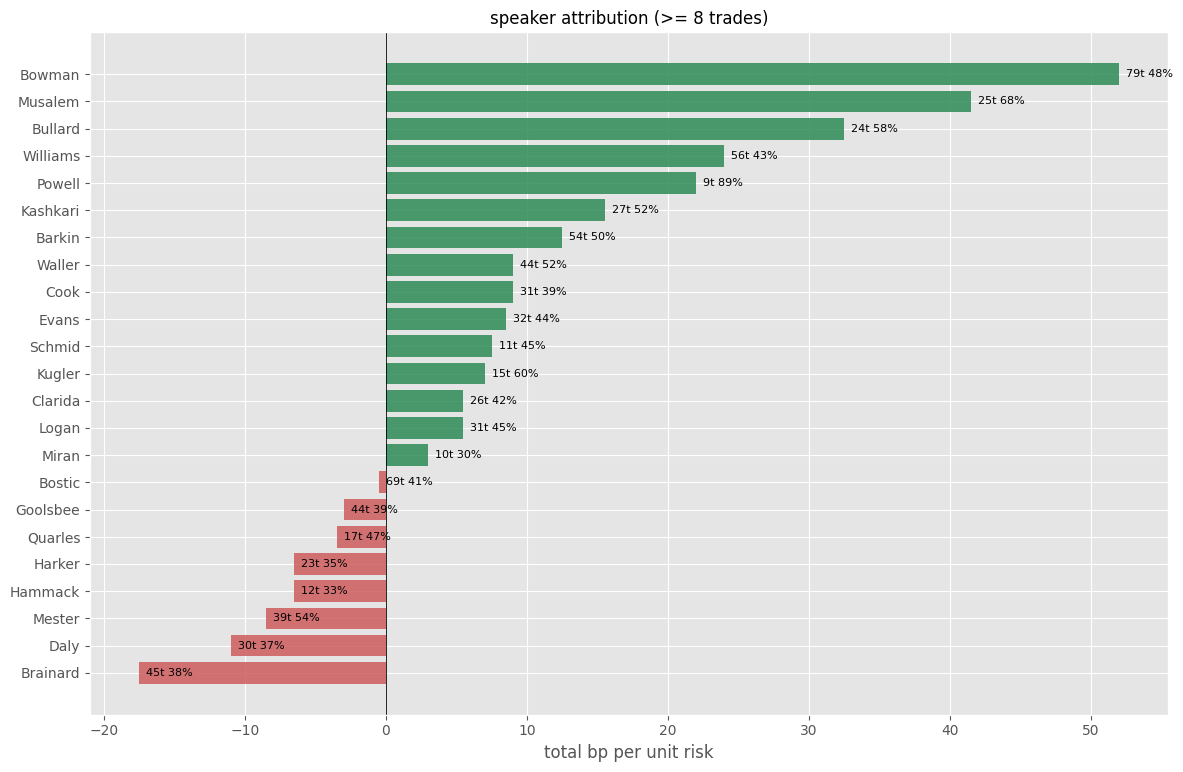

In [9]:
sp = (ann.groupby("speaker")
      .agg(trades=("pnl_bp", "size"), total_bp=("pnl_bp", "sum"),
           avg_bp=("pnl_bp", "mean"), hit=("profitable", "mean"))
      .sort_values("total_bp", ascending=False).round(4))
sp["role"] = [FX.role_of(s) for s in sp.index]
display(sp)

t = sp[sp.trades >= 8].sort_values("total_bp")
fig, ax = plt.subplots(figsize=(12, max(4, .34 * len(t))))
ax.barh(t.index, t.total_bp,
        color=["seagreen" if x > 0 else "indianred" for x in t.total_bp], alpha=.85)
ax.axvline(0, color="k", lw=.6); ax.set_xlabel("total bp per unit risk")
ax.set_title("speaker attribution (>= 8 trades)")
for i, (nm, r) in enumerate(t.iterrows()):
    ax.text(r.total_bp, i, f"  {int(r.trades)}t {r.hit:.0%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 5. Does the signal scale with conviction?

The most informative diagnostic available. A label that carries information should earn **more**
when it is more confident. On the pooled six-currency study the strongest bucket was the *worst*,
which was the main reason to doubt the whole idea.

by signed bucket:


,trades,total_bp,avg_bp,hit,t_stat
bucket,,,,,
-2,134,32.0,0.2388,0.4179,0.7922
-1,219,2.5,0.0114,0.4155,0.0539
1,241,92.0,0.3817,0.4938,1.5621
2,189,94.5,0.5000,0.5185,1.6828


by conviction |bucket|:


,trades,total_bp,avg_bp,hit,t_stat
abs_bucket,,,,,
1,460,94.5,0.2054,0.4565,1.2600
2,323,126.5,0.3916,0.4768,1.8304


hawk vs dove:


,trades,total_bp,avg_bp,hit,t_stat
direction,,,,,
dove (long fut),353,34.5,0.0977,0.4164,0.5614
hawk (short fut),430,186.5,0.4337,0.5047,2.2942


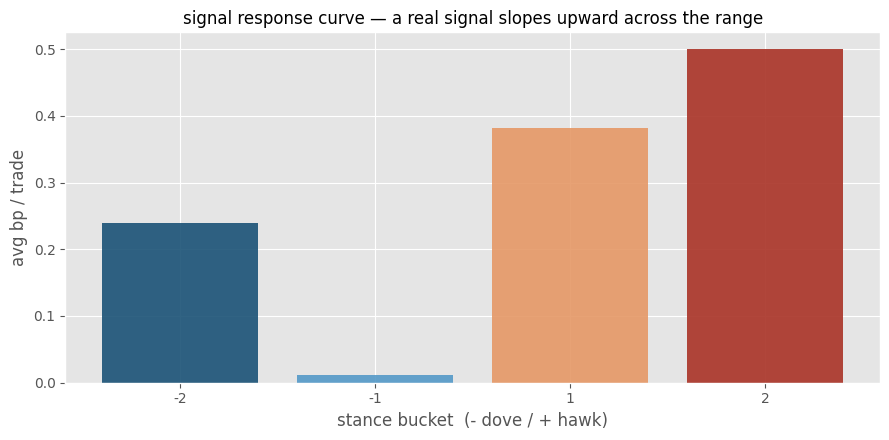

In [10]:
print("by signed bucket:");     display(blk(ann, "bucket"))
print("by conviction |bucket|:"); display(blk(ann, "abs_bucket"))
print("hawk vs dove:");          display(blk(ann, "direction"))

b = ann.groupby("bucket")["pnl_bp"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(b.index.astype(str), b.values,
       color=["#1a5276", "#5499c7", "#e59866", "#a93226"][:len(b)], alpha=.9)
ax.axhline(0, color="k", lw=.6)
ax.set_xlabel("stance bucket  (- dove / + hawk)"); ax.set_ylabel("avg bp / trade")
ax.set_title("signal response curve — a real signal slopes upward across the range")
plt.tight_layout(); plt.show()

## 6. Era, cycle and decay

The 2019-2021 book trades Eurodollar and the 2022-2026 book trades SOFR, so they are worth reading
separately — a difference between them is as likely to be about the contract as about the signal.

by instrument era:


,trades,total_bp,avg_bp,hit,t_stat
era,,,,,
Eurodollar (GE),239,37.5,0.1569,0.4059,1.2612
SOFR (SR3),544,183.5,0.3373,0.4908,1.8814


by year:


,trades,total_bp,avg_bp,hit,t_stat
year,,,,,
2019,92,37.0,0.4022,0.5109,1.4416
2020,49,-11.0,-0.2245,0.2653,-1.2653
2021,98,11.5,0.1173,0.3776,0.9605
2022,86,-27.5,-0.3198,0.4884,-0.5995
2023,99,80.0,0.8081,0.5455,1.6540
2024,116,69.0,0.5948,0.5517,1.5232
2025,154,58.5,0.3799,0.4610,1.1966
2026,89,3.5,0.0393,0.4045,0.1403


by FOMC cycle phase:


,trades,total_bp,avg_bp,hit,t_stat
cycle_phase,,,,,
0-14d after,264,16.0,0.0606,0.4848,0.3017
15-30d after,298,141.0,0.4732,0.4597,1.9502
30d+ / pre-meeting,73,35.0,0.4795,0.4795,0.8684


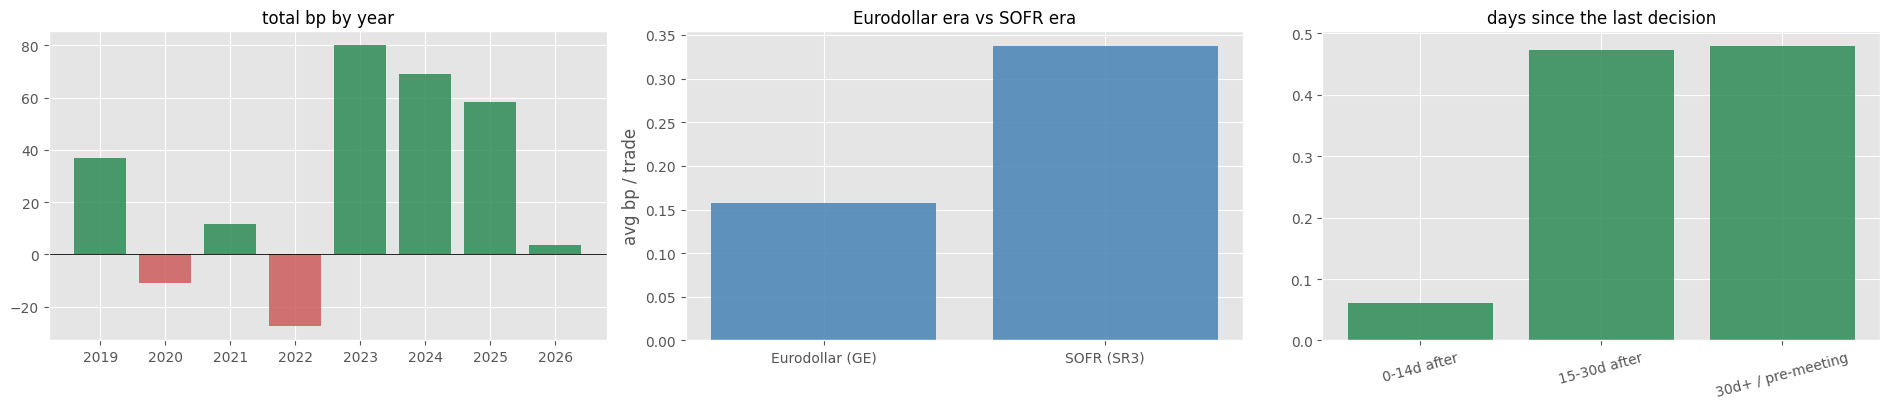

In [11]:
print("by instrument era:");  display(blk(ann, "era"))
print("by year:");            display(blk(ann, "year"))
print("by FOMC cycle phase:"); display(blk(ann, "cycle_phase"))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.2))
y = ann.groupby("year")["pnl_bp"].sum()
axes[0].bar(y.index.astype(str), y.values,
            color=["seagreen" if x > 0 else "indianred" for x in y.values], alpha=.85)
axes[0].axhline(0, color="k", lw=.6); axes[0].set_title("total bp by year")

e = ann.groupby("era")["pnl_bp"].mean()
axes[1].bar(e.index, e.values, color="steelblue", alpha=.85)
axes[1].axhline(0, color="k", lw=.6); axes[1].set_ylabel("avg bp / trade")
axes[1].set_title("Eurodollar era vs SOFR era")

c_ = ann.groupby("cycle_phase", observed=False)["pnl_bp"].mean()
axes[2].bar(c_.index.astype(str), c_.values,
            color=["seagreen" if x > 0 else "indianred" for x in c_.values], alpha=.85)
axes[2].axhline(0, color="k", lw=.6); axes[2].set_title("days since the last decision")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 7. Robustness

sign-flip permutation — the null is that the LABEL carried no direction:
  realized Sharpe 0.788   null -0.003 +- 0.366   p = 0.0136


,trades,total_bp,avg_bp,hit,sharpe,range
half,,,,,,
1st half,391,57.5,0.1471,0.4578,0.3832,2019-01-09 -> 2023-09-26
2nd half,392,163.5,0.4171,0.4719,1.2905,2023-09-27 -> 2026-08-07


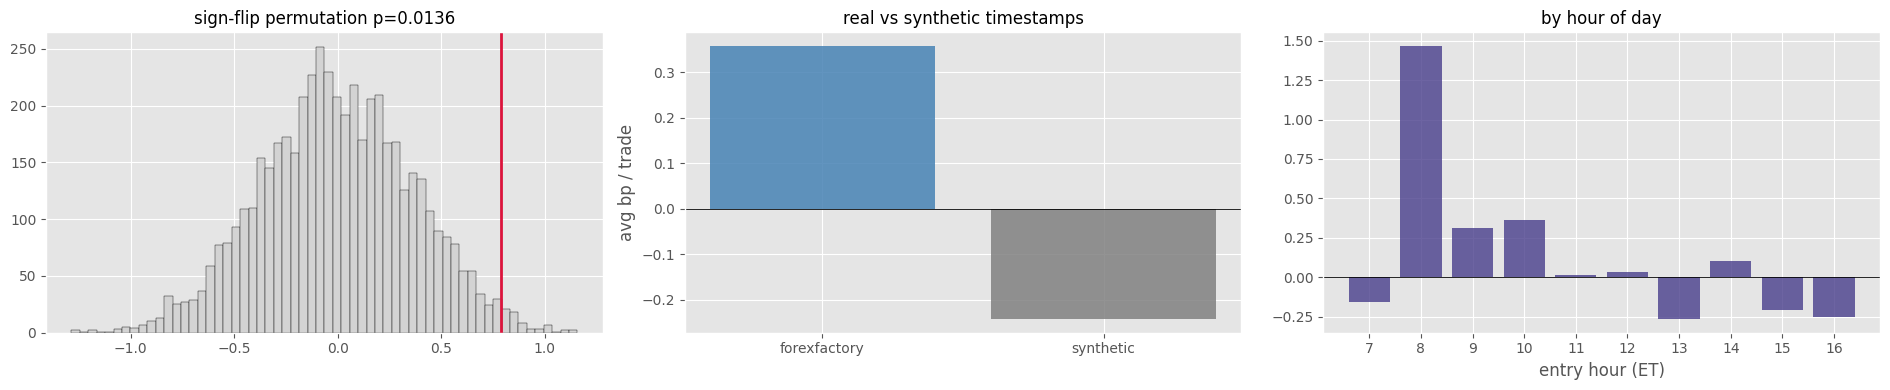

,size,sum,mean
timestamp_source,,,
forexfactory,684,245.0,0.3582
synthetic,99,-24.0,-0.2424


In [12]:
r = G.sign_flip_permutation(closed, n_perm=5000)
print("sign-flip permutation — the null is that the LABEL carried no direction:")
print(f"  realized Sharpe {r['realized_sharpe']:.3f}   null {r['perm_mean']:.3f}"
      f" +- {r['perm_std']:.3f}   p = {r['p_value']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(19, 4))
axes[0].hist(r["perm"], bins=60, color="lightgrey", edgecolor="k", lw=.3)
axes[0].axvline(r["realized_sharpe"], color="crimson", lw=2)
axes[0].set_title(f"sign-flip permutation p={r['p_value']:.4f}")

mid = len(closed) // 2
rows = []
for name, sub in [("1st half", closed.iloc[:mid]), ("2nd half", closed.iloc[mid:])]:
    s = G.summarize(sub)
    rows.append({"half": name, "trades": s["trades"], "total_bp": s["total"],
                 "avg_bp": s["avg"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
                 "range": f"{s['first'].date()} -> {s['last'].date()}"})
display(pd.DataFrame(rows).set_index("half").round(4))

prov = closed.groupby("timestamp_source")["pnl_bp"].agg(["size", "sum", "mean"])
axes[1].bar(prov.index, prov["mean"], color=["steelblue", "grey"][:len(prov)], alpha=.85)
axes[1].axhline(0, color="k", lw=.6); axes[1].set_ylabel("avg bp / trade")
axes[1].set_title("real vs synthetic timestamps")

h = ann.groupby(ann.opened_at.dt.hour)["pnl_bp"].mean()
axes[2].bar(h.index.astype(str), h.values, color="darkslateblue", alpha=.8)
axes[2].axhline(0, color="k", lw=.6); axes[2].set_xlabel("entry hour (ET)")
axes[2].set_title("by hour of day")
plt.tight_layout(); plt.show()
display(prov.round(4))

### 7.1 The comparison that matters

The hand labels against the **causal** schemes on identical machinery. The gap between them is the
value of knowing who the hawks actually are — and it is also the size of the hindsight this
notebook is carrying.

In [13]:
rows = []
for name, fname, tradeable in [("manual (hand, quarterly)", "closed_manual.pkl", False),
                               ("peer (causal)", "closed.pkl", True)]:
    p = CACHE / fname
    if not p.exists():
        continue
    with open(p, "rb") as f:
        d = pickle.load(f).get(BANK)
    if d is None or d.empty:
        continue
    s = G.summarize(d)
    rows.append({"labels": name, "point_in_time": tradeable, "trades": s["trades"],
                 "total_bp": s["total"], "avg_bp": s["avg"], "hit": s["hit_rate"],
                 "sharpe": s["sharpe"], "t_stat": s["t_stat"],
                 "net_at_0.25bp": s["total"] - .25 * s["trades"],
                 "first": str(s["first"].date())})
cmp = pd.DataFrame(rows).set_index("labels")
display(cmp.round(4))
print("The manual row is NOT tradeable as constructed. It is the ceiling: what a correct,")
print("quarterly-refreshed read of the committee would have been worth.")

,point_in_time,trades,total_bp,avg_bp,hit,sharpe,t_stat,net_at_0.25bp,first
labels,,,,,,,,,
"manual (hand, quarterly)",False,783,221.0,0.2822,0.4649,0.7876,2.1677,25.25,2019-01-09
peer (causal),True,473,103.5,0.2188,0.4567,0.6890,1.2427,-14.75,2023-05-05


The manual row is NOT tradeable as constructed. It is the ceiling: what a correct,
quarterly-refreshed read of the committee would have been worth.


## 8. Verdict

1. **Does it clear costs?** Break-even is `avg_bp`; a listed SR3 outright is roughly a quarter-tick
   round trip.
2. **Is the response ordered in conviction?** If the strongest bucket is not the best, the label is
   not measuring what it claims to.
3. **Is the voter split there?** The one conditioning variable here that is economically motivated
   rather than searched.
4. **Does the edge survive the era split?** If it is all Eurodollar or all SOFR, it is about the
   contract.
5. **How much of it is hindsight?** Compare against the causal `peer` row above.

In [14]:
summary = {
    "window": f"{closed.opened_at.min().date()} -> {closed.opened_at.max().date()}",
    "trades": int(len(closed)),
    "total_bp": round(float(closed.pnl_bp.sum()), 2),
    "avg_bp_per_trade": round(float(closed.pnl_bp.mean()), 4),
    "hit_rate": round(float(closed.profitable.mean()), 4),
    "sharpe": round(float(G.summarize(closed)["sharpe"]), 3),
    "t_stat": round(float(G.summarize(closed)["t_stat"]), 3),
    "sign_flip_p": round(float(r["p_value"]), 4),
    "net_at_0.25bp_all": round(float(closed.pnl_bp.sum() - .25 * len(closed)), 1),
    "net_at_0.25bp_real_ts": round(float(real.pnl_bp.sum() - .25 * len(real)), 1),
    "net_at_0.25bp_voters": round(float(vot.pnl_bp.sum() - .25 * len(vot)), 1),
    "conviction_1_avg_bp": round(float(ann[ann.abs_bucket == 1].pnl_bp.mean()), 4),
    "conviction_2_avg_bp": round(float(ann[ann.abs_bucket == 2].pnl_bp.mean()), 4),
    "presidents_voter_gap_bp": round(float(obs), 4),
    "presidents_voter_p": round(float(pval), 4),
    "point_in_time": False,
}
for k, v_ in summary.items():
    print(f"  {k:26s} {v_}")
pd.Series(summary).to_frame("value").to_csv(CACHE / "usd_fomc_manual_summary.csv")
print(f"\nwrote {CACHE / 'usd_fomc_manual_summary.csv'}")

  window                     2019-01-09 -> 2026-08-07
  trades                     783
  total_bp                   221.0
  avg_bp_per_trade           0.2822
  hit_rate                   0.4649
  sharpe                     0.788
  t_stat                     2.168
  sign_flip_p                0.0136
  net_at_0.25bp_all          25.3
  net_at_0.25bp_real_ts      74.0
  net_at_0.25bp_voters       134.8
  conviction_1_avg_bp        0.2054
  conviction_2_avg_bp        0.3916
  presidents_voter_gap_bp    1.005
  presidents_voter_p         0.0034
  point_in_time              False

wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\usd_fomc_manual_summary.csv


## 9. Trade log

In [15]:
log = ann[["opened_at", "closed_at", "speaker", "role", "district", "is_voter", "era",
           "symbol", "direction", "bucket", "days_to_fomc", "timestamp_source",
           "pnl_bp"]].copy()
log["cum_bp"] = log.pnl_bp.cumsum()
display(log.style.format({"pnl_bp": "{:+.3f}", "cum_bp": "{:+.2f}"})
        .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))
log.to_csv(CACHE / "usd_fomc_manual_trade_log.csv", index=False)
print(f"wrote {CACHE / 'usd_fomc_manual_trade_log.csv'}")

,opened_at,closed_at,speaker,role,district,is_voter,era,symbol,direction,bucket,days_to_fomc,timestamp_source,pnl_bp,cum_bp
0,2019-01-09 08:15:00-05:00,2019-01-09 12:00:00-05:00,Evans,President,Chicago,None,Eurodollar (GE),GEU19,dove (long fut),-1,749,forexfactory,+2.500,+2.50
1,2019-01-10 11:55:00-05:00,2019-01-10 15:40:00-05:00,Bullard,President,St. Louis,None,Eurodollar (GE),GEU19,dove (long fut),-2,748,forexfactory,-1.000,+1.50
2,2019-01-15 12:15:00-05:00,2019-01-15 16:00:00-05:00,George,President,Kansas City,None,Eurodollar (GE),GEU19,hawk (short fut),2,743,forexfactory,-0.500,+1.00
3,2019-01-17 10:00:00-05:00,2019-01-17 13:45:00-05:00,Quarles,Governor,-,True,Eurodollar (GE),GEU19,hawk (short fut),1,741,forexfactory,-1.000,+0.00
4,2019-01-18 08:20:00-05:00,2019-01-18 12:05:00-05:00,Williams,President (NY),New York,True,Eurodollar (GE),GEU19,dove (long fut),-1,740,forexfactory,-3.500,-3.50
5,2019-02-07 08:45:00-05:00,2019-02-07 12:30:00-05:00,Clarida,Governor,-,True,Eurodollar (GE),GEU19,dove (long fut),-1,720,forexfactory,+0.500,-3.00
6,2019-02-22 09:30:00-05:00,2019-02-22 13:15:00-05:00,Williams,President (NY),New York,True,Eurodollar (GE),GEU19,dove (long fut),-1,705,forexfactory,+2.000,-1.00
7,2019-02-25 10:15:00-05:00,2019-02-25 14:00:00-05:00,Clarida,Governor,-,True,Eurodollar (GE),GEU19,dove (long fut),-1,702,forexfactory,-0.500,-1.50
8,2019-02-28 07:15:00-05:00,2019-02-28 11:00:00-05:00,Clarida,Governor,-,True,Eurodollar (GE),GEU19,dove (long fut),-1,699,forexfactory,-3.000,-4.50
9,2019-03-05 07:00:00-05:00,2019-03-05 10:30:00-05:00,Rosengren,President,Boston,None,Eurodollar (GE),GEU19,hawk (short fut),1,694,forexfactory,+0.500,-4.00


wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\usd_fomc_manual_trade_log.csv
